In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
path = './dataset.txt'

df = pd.read_csv(path)

df.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [6]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.8 MB 22.5 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 25.5 MB/s eta 0:00:00


In [7]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(df.value.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 3.145186
p-value: 1.000000


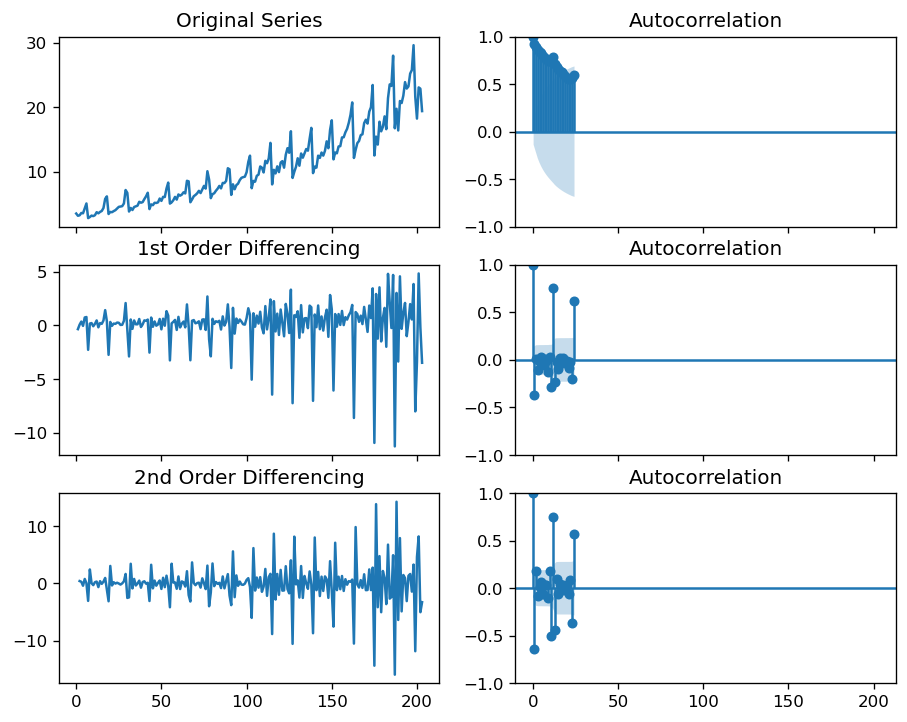

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})


# Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df.value); axes[0, 0].set_title('Original Series')
plot_acf(df.value, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df.value.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df.value.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df.value.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df.value.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

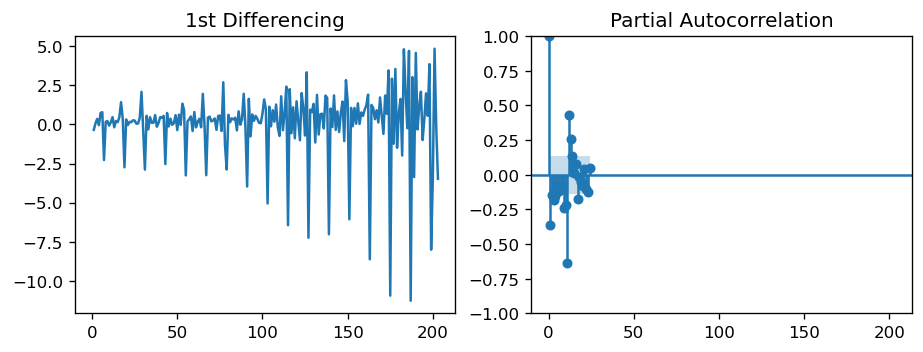

In [9]:
# PACF plot of 1st differenced series
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df.value.diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,5))
plot_pacf(df.value.diff().dropna(), ax=axes[1])

plt.show()

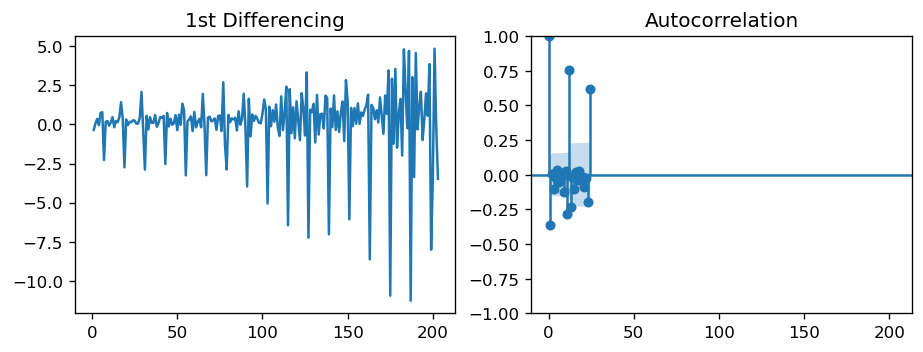

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df.value.diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_acf(df.value.diff().dropna(), ax=axes[1])

plt.show()

In [12]:
# Import the updated ARIMA class
from statsmodels.tsa.arima.model import ARIMA

# Assuming your DataFrame 'df' has a column 'value'
model = ARIMA(df['value'], order=(1, 1, 2))
model_fit = model.fit()  # Removed disp=0
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -424.570
Date:                Wed, 09 Apr 2025   AIC                            857.140
Time:                        23:28:45   BIC                            870.393
Sample:                             0   HQIC                           862.502
                                - 204                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4178      0.356      1.174      0.240      -0.280       1.115
ma.L1         -0.9546      0.377     -2.531      0.011      -1.694      -0.215
ma.L2          0.0969      0.272      0.356      0.7

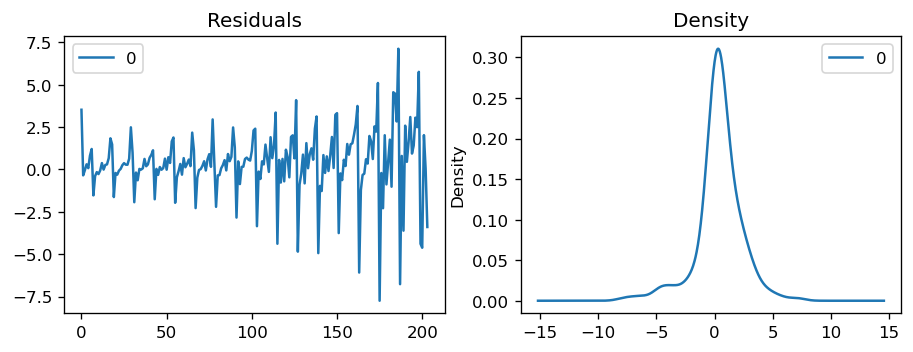

In [18]:
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

In [21]:
from statsmodels.tsa.stattools import acf

# Create Training and Test
train = df.value[:85]
test = df.value[85:]

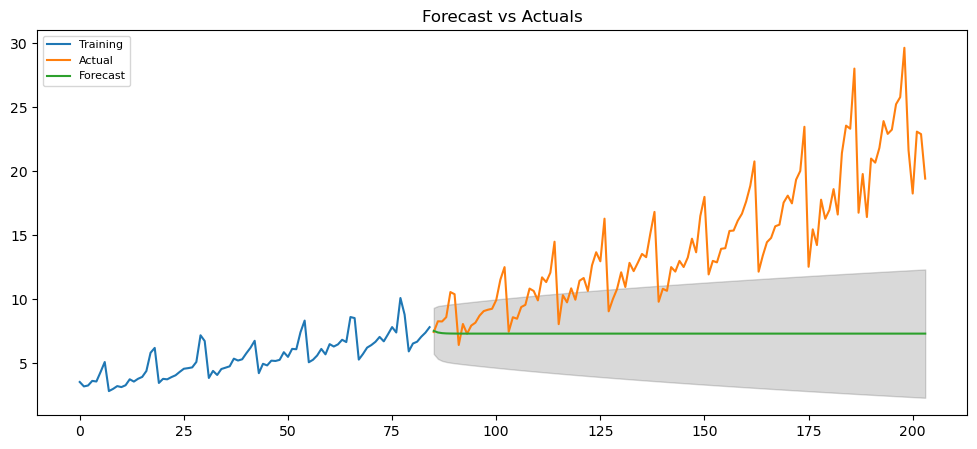

In [24]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

# Fit the model
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()  # Removed disp=-1

# Forecast
forecast_result = fitted.get_forecast(steps=119)
fc = forecast_result.predicted_mean
conf = forecast_result.conf_int(alpha=0.05)

# Make as pandas series
fc_series = pd.Series(fc, index=test.index)
lower_series = pd.Series(conf.iloc[:, 0], index=test.index)
upper_series = pd.Series(conf.iloc[:, 1], index=test.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(fc_series, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -116.886
Date:                Wed, 09 Apr 2025   AIC                            243.771
Time:                        23:39:37   BIC                            255.865
Sample:                             0   HQIC                           248.630
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2203      0.194     -1.138      0.255      -0.600       0.159
ar.L2         -0.3436      0.141     -2.443      0.015      -0.619      -0.068
ar.L3         -0.0935      0.252     -0.371      0.7

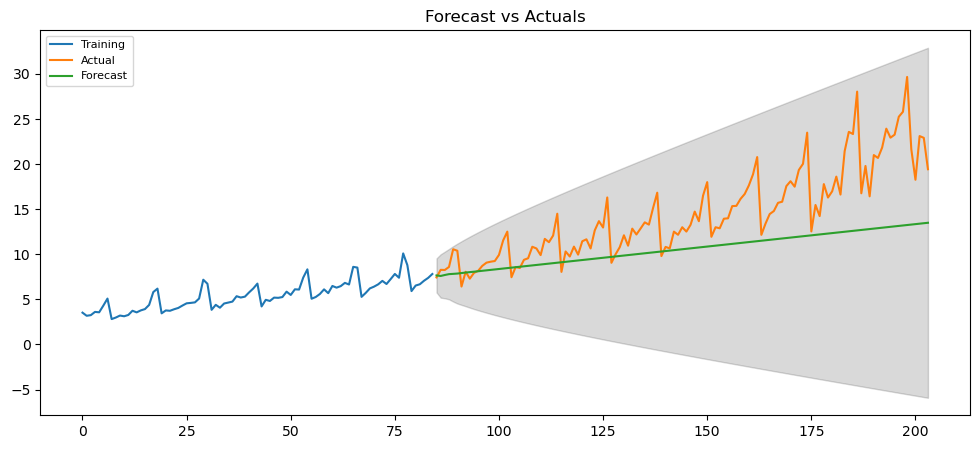

In [26]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

# Fit ARIMA model
model = ARIMA(train, order=(3, 2, 1))
fitted = model.fit()  # Removed disp=-1
print(fitted.summary())

# Forecast next 119 steps
forecast_result = fitted.get_forecast(steps=119)

# Extract forecast and confidence intervals
fc = forecast_result.predicted_mean
conf = forecast_result.conf_int(alpha=0.05)

# Convert to pandas series
fc_series = pd.Series(fc, index=test.index)
lower_series = pd.Series(conf.iloc[:, 0], index=test.index)
upper_series = pd.Series(conf.iloc[:, 1], index=test.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(fc_series, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()


In [31]:
!pip uninstall pmdarima -y
!pip install --no-binary :all: pmdarima


Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4


You can safely remove it manually.


     ---------------------------------------- 0.0/630.3 kB ? eta -:--:--
     ------------------------------------- 630.3/630.3 kB 23.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'


  error: subprocess-exited-with-error
  
  pip subprocess to install build dependencies did not run successfully.
  exit code: 1
  
  [444 lines of output]
  Ignoring numpy: markers 'python_version < "3.10"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.10" and platform_system != "Windows"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.10" and platform_system == "Windows"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.11"' don't match your environment
  Ignoring scipy: markers 'python_version <= "3.8" and platform_machine != "aarch64"' don't match your environment
  Ignoring scipy: markers 'python_version <= "3.8" and platform_machine == "aarch64"' don't match your environment
  Ignoring scipy: markers 'python_version == "3.9"' don't match your environment
  Ignoring scipy: markers 'python_version == "3.10"' don't match your environment
  Ignoring scipy: markers 'python_version == "3.11"' don't

In [33]:
!pip install numpy==1.24.4 pmdarima==2.0.3 --force-reinstall


     ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
     --------------------- ------------------ 5.8/10.9 MB 29.3 MB/s eta 0:00:01
     --------------------------------------- 10.9/10.9 MB 28.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\luthi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\luthi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\luthi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_requires_for_build_wheel
      backend = _build_backend()
                ^^^^^^^^^^^^^^^^
    File "C:\Users\luthi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\pip\_